In [1]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.model_selection import cross_val_score, GridSearchCV

from sklearn.dummy import DummyClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier

from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.metrics import classification_report


df = pd.read_csv('historical_data.csv')

### Dataset Info ###
Antal rader: 12000
Antal kolumner: 18

Datatyper:
int64      11
str         4
float64     3
Name: count, dtype: int64

Saknade värden per kolumn:
region                        340
price                         818
time_to_first_response_min    590
dtype: int64


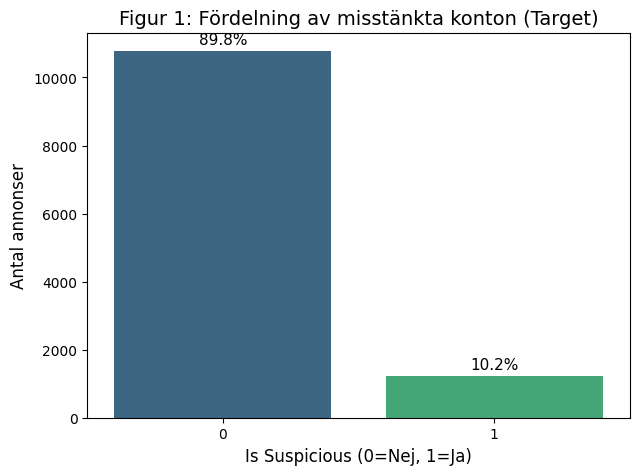

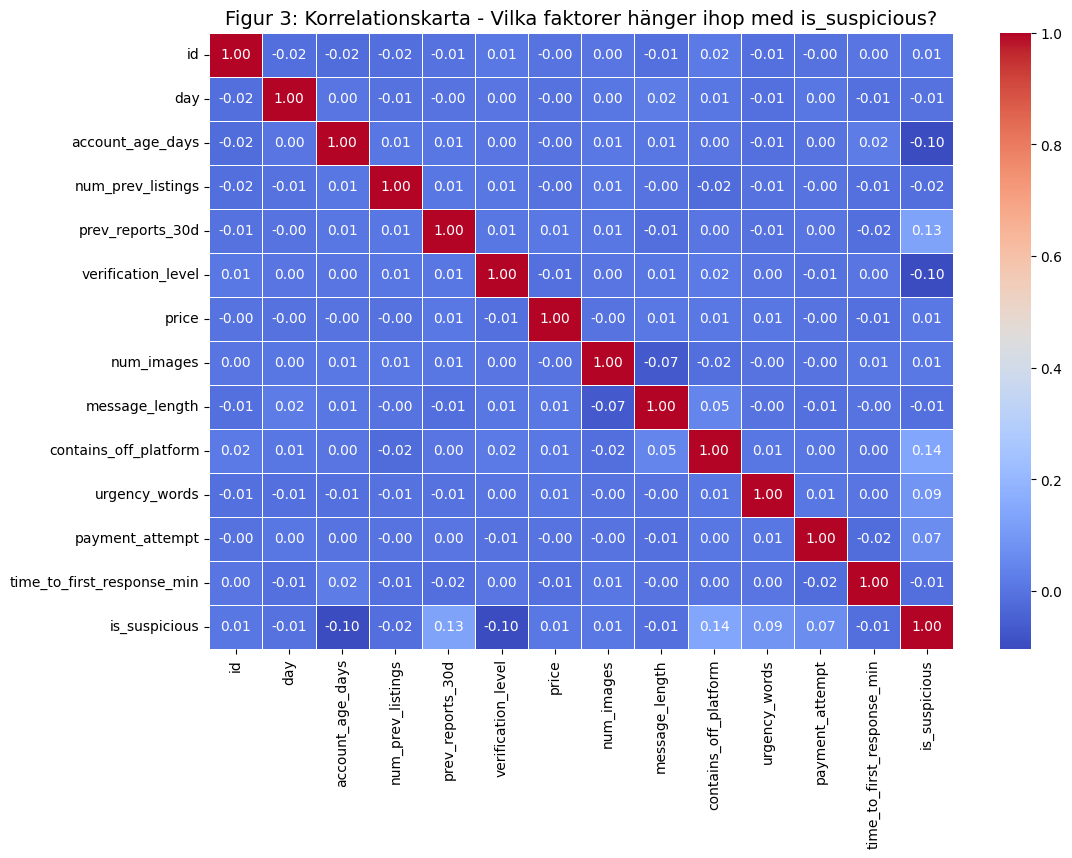

In [2]:
print("### Dataset Info ###")
print(f"Antal rader: {df.shape[0]}")
print(f"Antal kolumner: {df.shape[1]}")
print("\nDatatyper:")
print(df.dtypes.value_counts())


missing_values = df.isnull().sum()
print("\nSaknade värden per kolumn:")
print(missing_values[missing_values > 0])


plt.figure(figsize=(7, 5))
ax = sns.countplot(x='is_suspicious', data=df, palette='viridis', hue='is_suspicious', legend=False)
plt.title('Figur 1: Fördelning av misstänkta konton (Target)', fontsize=14)
plt.xlabel('Is Suspicious (0=Nej, 1=Ja)', fontsize=12)
plt.ylabel('Antal annonser', fontsize=12)

total = len(df)
for p in ax.patches:
    percentage = f'{100 * p.get_height() / total:.1f}%'
    ax.annotate(percentage, (p.get_x() + p.get_width() / 2., p.get_height()), 
                ha='center', va='baseline', fontsize=11, color='black', xytext=(0, 5),
                textcoords='offset points')

plt.show()


plt.figure(figsize=(12, 8))
numeric_df = df.select_dtypes(include=['number'])
corr = numeric_df.corr()
sns.heatmap(corr, annot=True, cmap='coolwarm', fmt='.2f', linewidths=0.5)

plt.title('Figur 3: Korrelationskarta - Vilka faktorer hänger ihop med is_suspicious?', fontsize=14)
plt.show()

Man kan se tecken till starkare kopplingar med is_suspicious och kategorierna contains_off_platform (0.14), prev_reports_30d(0.13) samt urgency_words(0.09). Medan vi kan se ingen koppling eller extremt svag koppling i kategorier som account_age_days(-0.10) och verification_level (-0.10). Vilket kan tyda på att ju äldre och mer verfikation det är på kontot ju mindre koppling kan vi se.

In [3]:
y = df["is_suspicious"]
X = df.drop(columns=["is_suspicious"])


X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.25,
    random_state=42,
    stratify=y
)

numeric_features = X.select_dtypes(include=['number']).columns
categorical_features = X.select_dtypes(include=['object']).columns

print("Train shape:", X_train.shape, "| Test shape:", X_test.shape)
print("Train target rate:", y_train.mean(), "| Test target rate:", y_test.mean())

Train shape: (9000, 17) | Test shape: (3000, 17)
Train target rate: 0.102 | Test target rate: 0.102


C:\Users\ahlar\AppData\Local\Temp\ipykernel_17496\553827285.py:13: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  categorical_features = X.select_dtypes(include=['object']).columns


In [4]:
numeric_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

categorical_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(
        handle_unknown="ignore",
        sparse_output=False
    ))
])

preprocess = ColumnTransformer(
    transformers=[
        ("num", numeric_transformer, numeric_features),
        ("cat", categorical_transformer, categorical_features)
    ],
    remainder="drop"
)

In [5]:
# Baseline med DummyClassifier

baseline_pipe = Pipeline([
    ("preprocess", preprocess),
    ("model", DummyClassifier(strategy="stratified"))
])

baseline_pipe.fit(X_train, y_train)

# LogisticRegression

logreg_pipe = Pipeline([
    ("preprocess", preprocess),
    ("model", LogisticRegression(
        max_iter=1000,
        random_state=42
    ))
])

logreg_pipe.fit(X_train, y_train)

# RandomForestClassifier

rfc_pipe = Pipeline ([
    ("preprocess", preprocess),
    ("model", RandomForestClassifier(
        n_estimators=100,
        random_state=42
    ))
])

rfc_pipe.fit(X_train, y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('preprocess', ...), ('model', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transformers cont

In [6]:
# Jämföra modeller (CrossValidation)

models = {
    "Baseline": baseline_pipe,
    "LogisticRegression": logreg_pipe,
    "RandomForestClassifier": rfc_pipe
}

results = []

for name, model in models.items():
    cv_scores = cross_val_score(model, X_train, y_train, cv=5, scoring="recall")
    
    results.append({
        "model": name,
        "recall_mean": cv_scores.mean(),
        "recall_std": cv_scores.std()
    })

results_df = pd.DataFrame(results)
results_df.sort_values("recall_mean", ascending=False)

,model,recall_mean,recall_std
0,Baseline,0.101271,0.022827
1,LogisticRegression,0.043567,0.003373
2,RandomForestClassifier,0.016334,0.010343


- Vi valde recall som huvudmetrik då det är viktigare att fånga så många misstänkta fall som möjligt
- LogisticRegression presterade bättre än RandomForestClassifier men båda hade låg träffprocent och presterade sämre än Baseline (stratified)
- Att båda modellerna missade många misstänkta fall kan bero på den obalanserade datan och att standardtröskeln på 0.5 inte är optimalt för detta case

In [8]:
# Optimera LogisticRegression med GridSearchCV

param_grid = {
    'model__C': [0.1, 1, 10],                           # Mindre C ger starkare regularisering, vilket kan hjälpa till att hantera obalanserade data. 
    'model__penalty': ['l2'],                           # L2 fungerar bra för att hantera obalanserade data med hög class_weight, fungerar med lbfgs.
    'model__solver': ['lbfgs', 'liblinear'],            # lbfgs är snabbare och fungerar bra med L2.
    'model__class_weight': [                            # Olika nivåer av class_weight för att hantera obalansen i data, ju mer aggressiv desto fler FP.
        {0:1, 1:10},
        {0:1, 1:15},
        {0:1, 1:18},
        'balanced',
        ],
    'model__max_iter': [100, 300]                   
}

grid_search = GridSearchCV(
    estimator=logreg_pipe,
    param_grid=param_grid,
    cv=5,
    scoring='recall',
    n_jobs=-1,
    verbose=1,
    return_train_score=True
)

grid_search.fit(X_train, y_train)

print('Bästa parametrar:', grid_search.best_params_)
print('Bästa CV-score (recall):', grid_search.best_score_)

best_model = grid_search.best_estimator_                # Vår bästa modell efter GridSearchCV.
y_pred_train = best_model.predict(X_train)              # Utvärderar modellen, för att jämföra resultat med test-data.

print('-' * 60)
print('\nClassification Report - Träningsdata (bästa modellen)')
print(classification_report(y_train, y_pred_train))

flagged_as_suspicious = (y_pred_train == 1).mean()      # Hur stor andel som flaggas, högre = fler FP.
print(f'Andel flaggade: {flagged_as_suspicious:.1%}')

y_pred_test = best_model.predict(X_test)

print('-' * 60)
print('\nClassification Report - Testdata (bästa modellen)')
print(classification_report(y_test, y_pred_test))

flagged_as_suspicious_test = (y_pred_test == 1).mean()
print(f'Andel flaggade: {flagged_as_suspicious_test:.1%}')

Fitting 5 folds for each of 48 candidates, totalling 240 fits
Bästa parametrar: {'model__C': 0.1, 'model__class_weight': {0: 1, 1: 18}, 'model__max_iter': 100, 'model__penalty': 'l2', 'model__solver': 'lbfgs'}
Bästa CV-score (recall): 0.8954205274411976
------------------------------------------------------------

Classification Report - Träningsdata (bästa modellen)
              precision    recall  f1-score   support

           0       0.97      0.36      0.52      8082
           1       0.14      0.90      0.24       918

    accuracy                           0.41      9000
   macro avg       0.55      0.63      0.38      9000
weighted avg       0.89      0.41      0.49      9000

Andel flaggade: 66.9%
------------------------------------------------------------

Classification Report - Testdata (bästa modellen)
              precision    recall  f1-score   support

           0       0.96      0.35      0.52      2694
           1       0.13      0.87      0.23       306

    a

c:\Users\ahlar\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\linear_model\_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', and C=np.inf instead of penalty=None.
  warnings.warn(


* Vårt mål är att hitta så många suspekta kunder som möjligt genom en hög 'recall' men ändå balansera mängden FP som flaggas för en rimlig arbetsmängd.
* Detta görs genom class_weight där klass 1 får större vikt, det medför bättre 'recall' men betydligt sämre 'precision'.
* Då vi ska skapa en Top-X-strategi är 'precision' inte lika viktigt genom hela datasetet, det är viktigare att en större del av högrisk-fallen flaggas korrekt så resurser för granskare används effektivt.